# 1. Introduction

In this tutorial, we demonstrate how to use Normet to perform weather normalisation of a target variable (e.g., pollutant concentration, energy demand, sales) using two AutoML backends: FLAML and LightGBM.

We will cover:
- Training FLAML and LightGBM models for weather normalisation.
- Saving and reloading models.
- Applying rolling weather normalisation to handle temporal drift.

# 2. Load Dataset

In [1]:
import normet as nm
from _synth import make_my1_data

features_to_use = [
    "u10", "v10", "d2m", "t2m", "blh", "sp", "ssrd", "tcc", "tp", "rh2m"
]
my1_raw = make_my1_data().set_index('date')
df_pre = nm.prepare_data(my1_raw, value='PM2.5', feature_names=features_to_use)
df_pre = df_pre.set_index('date')
df_pre.head()

,u10,v10,d2m,t2m,blh,sp,ssrd,tcc,tp,rh2m,value,date_unix,day_julian,weekday,hour,set
date,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,-2.720528,1.545010,277.183465,278.394725,384.209053,102252.303312,-1.164153e-10,0.650958,0.000008,91.884130,58.1,1577836,1,3,0,training
2020-01-01 01:00:00,-2.308789,1.282742,276.695430,277.772899,353.220263,102211.168636,-1.164153e-10,0.603699,0.000002,92.715877,43.2,1577840,1,3,1,training
2020-01-01 02:00:00,-2.216471,0.758730,276.505662,277.463419,255.911846,102174.855967,-1.164153e-10,0.710378,0.000005,93.485560,43.0,1577844,1,3,2,testing
2020-01-01 03:00:00,-1.928623,0.509013,276.412816,277.305813,191.375560,102166.786485,-1.164153e-10,0.837765,0.000005,93.906363,42.8,1577847,1,3,3,training
2020-01-01 04:00:00,-1.700043,0.607069,276.553051,277.478941,151.780210,102142.578039,-1.164153e-10,0.819103,0.000003,93.696878,36.8,1577851,1,3,4,testing


In [2]:
# Shared feature configuration used throughout this notebook
feature_names = [
    "u10", "v10", "d2m", "t2m", "blh", "sp", "ssrd", "tcc", "tp", "rh2m",
    "date_unix", "day_julian", "weekday", "hour",
]
variables_resample = ["u10", "v10", "d2m", "t2m", "blh", "sp", "ssrd", "tcc", "tp", "rh2m"]

Expected columns:
- pollutant (target variable to normalise)
- temperature, wind_speed, humidity (predictor variables)
- Optional: set column to indicate training/test split

# 3. Weather normalisation

# 3.1 Weather normalisation with FLAML

In [3]:
#Load pre trained model
import normet as nm
from normet.utils.logging import enable_default_logging, get_logger
enable_default_logging(level="INFO")
log = get_logger("tutorial.model_training")


In [4]:
model_flaml=nm.load_model(path='.',filename='automl.joblib')
df_normalised=nm.normalise(df_pre, model_flaml,
                           feature_names=feature_names, #features used for model training
                          variables_resample=variables_resample, #variables for resampling
                          n_samples=300,aggregate=True)

[06/20/26 22:58:44] INFO     Loaded FLAML model from automl.joblib                             ]8;id=5873640;file:///Users/user/Documents/GitHub/normet-py/src/normet/backends/flaml_backend.py\flaml_backend.py]8;;\:]8;id=5873641;file:///Users/user/Documents/GitHub/normet-py/src/normet/backends/flaml_backend.py#138\138]8;;\

In [5]:
df_normalised.head()

,observed,normalised
date,,
2020-01-01 00:00:00,58.1,26.630335
2020-01-01 01:00:00,43.2,26.725071
2020-01-01 02:00:00,43.0,26.269460
2020-01-01 03:00:00,42.8,26.769277
2020-01-01 04:00:00,36.8,26.199798


<Axes: xlabel='date'>

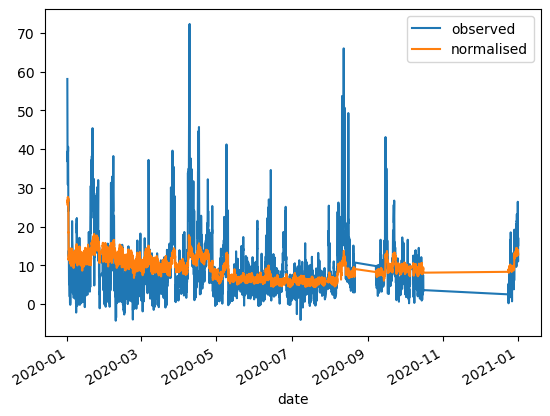

In [6]:
import matplotlib.pyplot as plt
import matplotlib
df_normalised.plot()

In [7]:
df_normalised_all=nm.normalise(df_pre, model_flaml,
                           feature_names=feature_names, #features used for model training
                          variables_resample=variables_resample, #variables for resampling
                          n_samples=300,aggregate=False)

In [8]:
df_normalised_all.head()

,observed,2406,5035,6374,15807,20564,21247,22819,24892,27540,...,970632,972475,973261,973405,977095,985695,987065,991790,992444,994420
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,58.1,24.611881,20.054773,20.553517,34.779900,23.104743,18.720166,26.665394,23.415628,27.948470,...,27.014761,14.766805,34.452778,30.136728,23.324054,17.218690,32.160436,18.754000,21.357866,18.741846
2020-01-01 01:00:00,43.2,41.728582,38.276056,25.094910,19.068574,30.658577,21.699701,27.209669,24.179640,48.341571,...,23.990278,29.926206,35.116468,38.030650,51.075836,22.910270,29.997843,24.079120,40.042348,41.438476
2020-01-01 02:00:00,43.0,20.450029,32.382528,15.558271,19.730869,17.864384,33.641333,28.461154,19.639908,17.027310,...,15.277694,31.747033,33.690627,50.965284,28.963142,30.187660,20.777032,24.041846,42.098059,45.078803
2020-01-01 03:00:00,42.8,17.738648,34.748085,38.523371,19.153238,19.719539,17.938975,16.355390,22.856923,20.682528,...,25.448694,32.097290,21.725081,25.547257,44.312449,30.128996,32.417426,36.917016,25.444243,26.059054
2020-01-01 04:00:00,36.8,18.145773,20.461133,14.470040,38.757009,25.816772,19.627024,33.638003,37.614604,21.714688,...,32.871620,33.116283,35.931786,23.138975,22.163463,37.724123,29.076272,19.266852,32.470890,40.446902


# 3.2 Weather normalisation with LightGBM

In [9]:
model_lgb=nm.load_model(path='.',backend='lightgbm',filename='automl_lgb.joblib')

[06/20/26 22:59:09] INFO     Loaded LightGBM model from automl_lgb.joblib                        ]8;id=5873648;file:///Users/user/Documents/GitHub/normet-py/src/normet/backends/lgb_backend.py\lgb_backend.py]8;;\:]8;id=5873649;file:///Users/user/Documents/GitHub/normet-py/src/normet/backends/lgb_backend.py#205\205]8;;\

In [10]:
df_normalised_lgb=nm.normalise(df_pre, model_lgb,
                           feature_names=feature_names, #features used for model training
                          variables_resample=variables_resample, #variables for resampling
                          n_samples=300,aggregate=True)

<Axes: xlabel='date'>

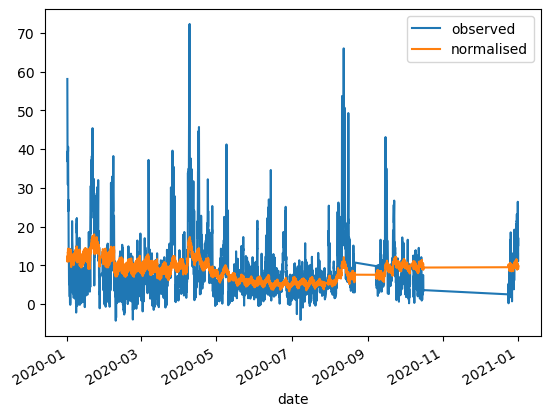

In [11]:
df_normalised_lgb.plot()

<Axes: xlabel='date'>

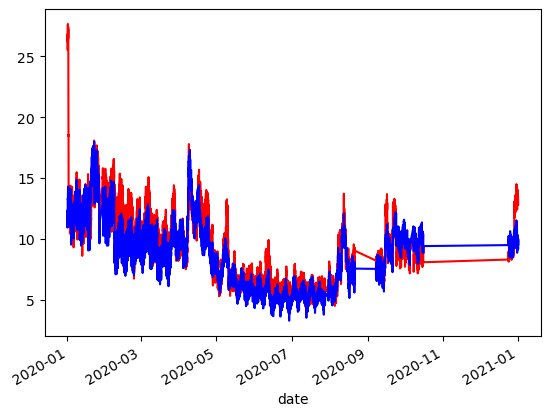

In [12]:
fig,ax=plt.subplots()
df_normalised['normalised'].plot(c='r')
df_normalised_lgb['normalised'].plot(c='b')

In [13]:
df_normalised_all_lgb=nm.normalise(df_pre, model_lgb,
                           feature_names=feature_names, #features used for model training
                          variables_resample=variables_resample, #variables for resampling
                          n_samples=300,aggregate=False)

In [14]:
df_normalised_all_lgb.head()

,observed,2406,5035,6374,15807,20564,21247,22819,24892,27540,...,970632,972475,973261,973405,977095,985695,987065,991790,992444,994420
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,58.1,3.161043,4.026672,10.325120,12.845894,12.304969,4.046702,8.833154,8.633581,14.185306,...,10.919783,5.833282,27.584706,14.019358,14.354426,6.048825,10.701221,2.259054,3.778799,9.035739
2020-01-01 01:00:00,43.2,23.431872,19.171934,21.055243,4.998867,11.056091,5.122703,12.794580,5.614943,22.103189,...,13.066640,16.159226,19.853610,23.758961,24.777563,6.750470,15.436147,8.216988,31.669828,23.677051
2020-01-01 02:00:00,43.0,8.102493,15.902222,0.669656,2.997959,5.200700,22.491131,11.855313,3.207024,3.121470,...,1.153303,19.878439,19.551361,23.256292,7.294833,17.967379,6.444559,16.669021,27.842012,30.008989
2020-01-01 03:00:00,42.8,4.590763,19.471722,23.599792,3.775773,6.645899,5.813832,8.474538,10.659264,6.267666,...,21.626689,18.998931,7.091645,20.140037,30.897134,15.234144,12.613655,18.916481,12.423285,15.154390
2020-01-01 04:00:00,36.8,3.962894,5.154811,3.327548,22.827481,11.121476,3.451267,22.661522,29.166952,7.026512,...,20.411502,18.900214,22.481044,10.581963,11.551760,23.264258,18.517809,3.833684,23.692568,19.896850


# 3.3 Weather normalisation with user-defined weather dataset

In [15]:
# Selected weather dataset
custom_weather=df_pre.reset_index().iloc[0:100][variables_resample]

In [16]:
custom_weather

,u10,v10,d2m,t2m,blh,sp,ssrd,tcc,tp,rh2m
0,-2.720528,1.545010,277.183465,278.394725,384.209053,102252.303312,-1.164153e-10,0.650958,8.122856e-06,91.884130
1,-2.308789,1.282742,276.695430,277.772899,353.220263,102211.168636,-1.164153e-10,0.603699,2.233786e-06,92.715877
2,-2.216471,0.758730,276.505662,277.463419,255.911846,102174.855967,-1.164153e-10,0.710378,4.975250e-06,93.485560
3,-1.928623,0.509013,276.412816,277.305813,191.375560,102166.786485,-1.164153e-10,0.837765,4.873714e-06,93.906363
4,-1.700043,0.607069,276.553051,277.478941,151.780210,102142.578039,-1.164153e-10,0.819103,2.995303e-06,93.696878
...,...,...,...,...,...,...,...,...,...,...
95,2.382450,0.898623,277.286818,278.536809,159.740633,102677.427238,-1.164153e-10,0.665897,0.000000e+00,91.643696
96,1.953356,3.282828,278.385969,280.142238,577.792066,102066.508411,-1.164153e-10,0.992543,3.046071e-07,88.578482
97,2.152209,3.542742,278.420706,280.367661,720.511077,102008.250688,-1.164153e-10,1.000005,5.584464e-07,87.431927
98,2.212770,3.903066,278.022302,280.524312,828.002633,101947.729573,-1.164153e-10,0.993077,1.015357e-07,84.133213


In [17]:
# Weather normalisation using flaml
df_norm_custom=nm.normalise(df_pre, model_flaml,resample_df=custom_weather,
                           feature_names=feature_names, #features used for model training
                          variables_resample=variables_resample, #variables for resampling
                          n_samples=300,aggregate=True)

In [18]:
# Weather normalisation using lightgbm
df_norm_custom_lgb=nm.normalise(df_pre, model_lgb,resample_df=custom_weather,
                           feature_names=feature_names, #features used for model training
                          variables_resample=variables_resample, #variables for resampling
                          n_samples=300,aggregate=True)

<Axes: xlabel='date'>

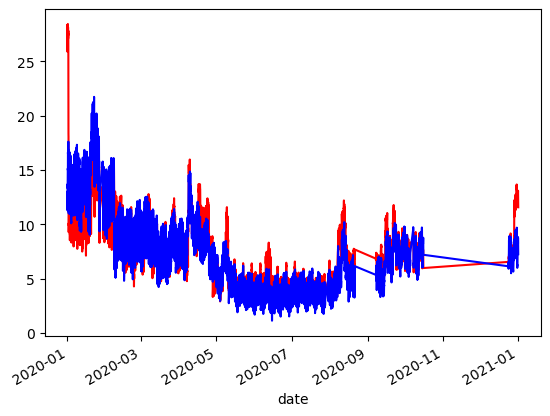

In [19]:
#Flaml vs. lightgbm
fig,ax=plt.subplots()
df_norm_custom['normalised'].plot(c='r')
df_norm_custom_lgb['normalised'].plot(c='b')

<Axes: xlabel='date'>

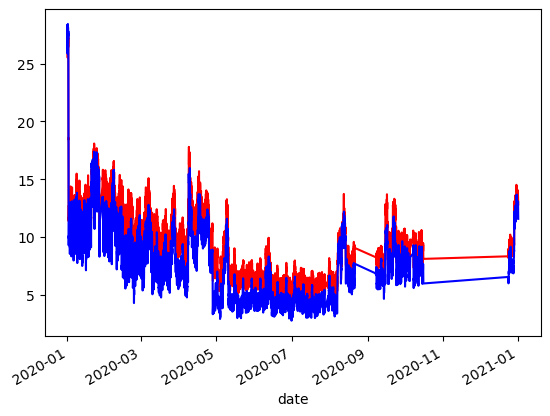

In [20]:
#Whole weather dataset vs. selected weather dataset using flaml
fig,ax=plt.subplots()
df_normalised['normalised'].plot(c='r')
df_norm_custom['normalised'].plot(c='b')

<Axes: xlabel='date'>

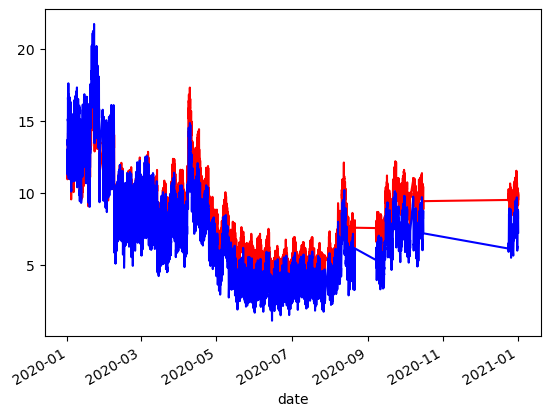

In [21]:
#Whole weather dataset vs. selected weather dataset using lightgbm
fig,ax=plt.subplots()
df_normalised_lgb['normalised'].plot(c='r')
df_norm_custom_lgb['normalised'].plot(c='b')

# 4. Rolling weather normalisation

In [22]:
#Rolling based on flaml model
df_norm_rolling=nm.rolling(df_pre,value='value', model=model_flaml,feature_names=feature_names,
                    variables_resample=variables_resample,
                    n_samples=100,window_days=14, rolling_every=7)

In [23]:
df_norm_rolling.head()

,observed,rolling_0,rolling_1,rolling_2,rolling_3,rolling_4,rolling_5,rolling_6,rolling_7,rolling_8,...,rolling_33,rolling_34,rolling_35,rolling_36,rolling_37,rolling_38,rolling_39,rolling_40,rolling_41,rolling_50
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,58.1,24.443036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 01:00:00,43.2,22.667351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:00:00,43.0,22.870747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 03:00:00,42.8,22.406955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 04:00:00,36.8,23.328147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='date'>

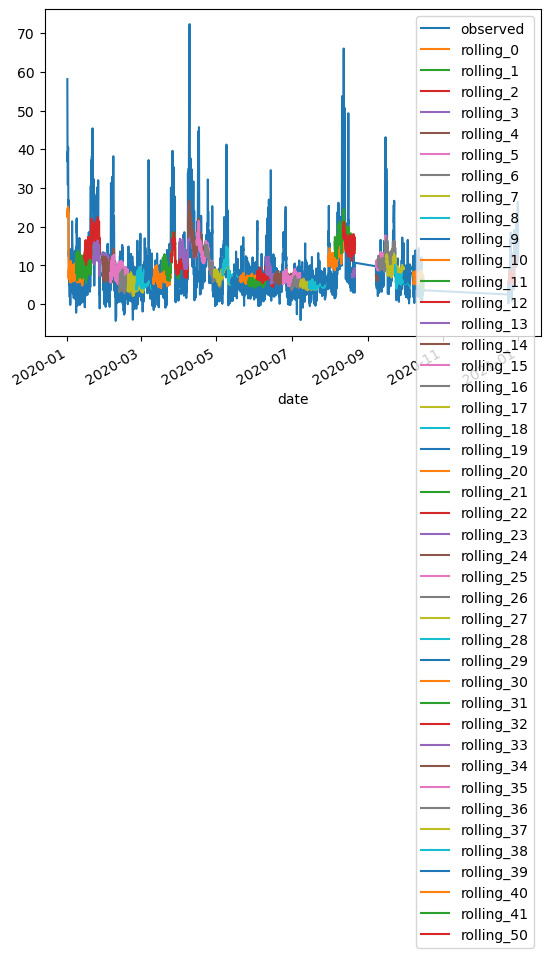

In [24]:
df_norm_rolling.plot()

In [25]:
#Rolling based on lightgbm model
df_norm_rolling_lgb=nm.rolling(df_pre,value='value', model=model_lgb,feature_names=feature_names,
                    variables_resample=variables_resample,
                    n_samples=100,window_days=14, rolling_every=7)

<Axes: xlabel='date'>

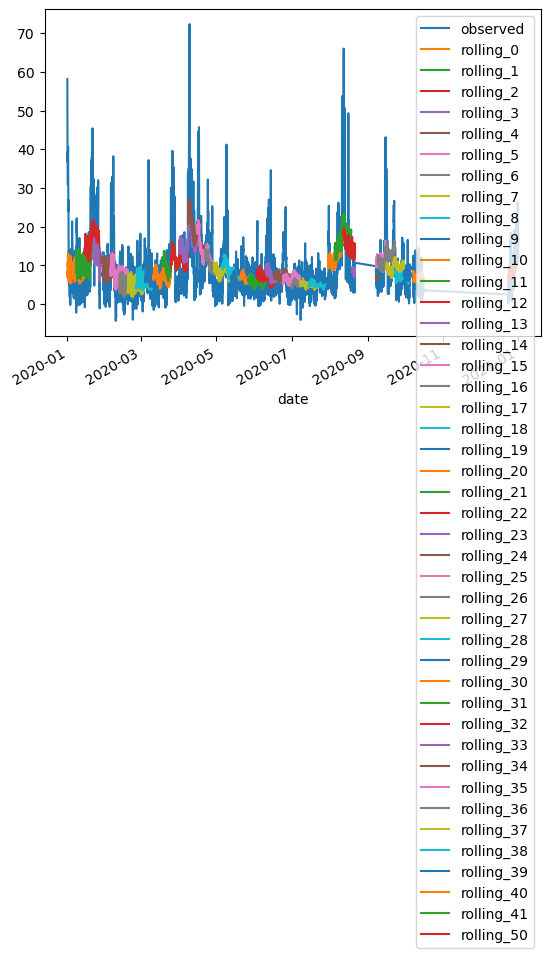

In [26]:
df_norm_rolling_lgb.plot()

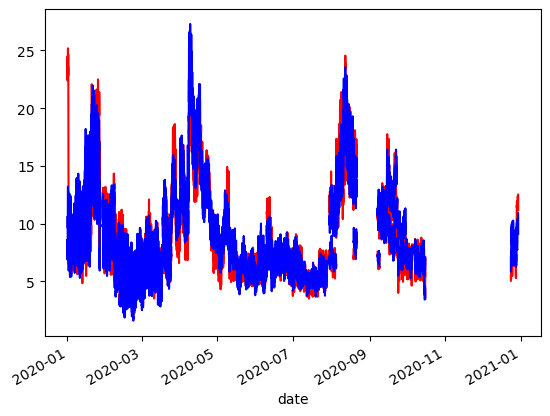

In [27]:
fig,ax=plt.subplots()
df_norm_rolling.iloc[:,1:].plot(c='r',ax=ax)
df_norm_rolling_lgb.iloc[:,1:].plot(c='b',ax=ax)
ax.legend().set_visible(False) 

# 5. Automated pipeline from data preparation to weather normalisation

In [28]:
from _synth import make_my1_data
my1 = make_my1_data().set_index('date')

In [29]:
#do_all function, using flaml backend as default
df_normalise, model_flaml, df_pre = nm.do_all(
    my1,
    value="PM2.5",
    feature_names=feature_names,
    variables_resample=variables_resample,
    n_samples=300,
    model_config={"time_budget": 10, "metric": "r2", "estimator_list": ["lgbm"], "task": "regression"}
)

[06/20/26 22:59:45] INFO     Starting do_all | backend=flaml | value=PM2.5 | n_samples=300            ]8;id=5873656;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873657;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#138\138]8;;\

                    INFO     Dropped 2411 rows with NA in target.                                    ]8;id=5873664;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873665;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#210\210]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5873671;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873672;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

                    INFO     Data prepared: 6373 rows (4780 training, 1593 testing)                   ]8;id=5873678;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873679;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#155\155]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5873684;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873685;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

[06/20/26 22:59:56] INFO     Model trained with backend=flaml                                          ]8;id=5873692;file:///Users/user/Documents/GitHub/normet-py/src/normet/model/train.py\train.py]8;;\:]8;id=5873693;file:///Users/user/Documents/GitHub/normet-py/src/normet/model/train.py#145\145]8;;\

                    INFO     Model trained with backend=flaml                                         ]8;id=5873699;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873700;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#174\174]8;;\

[06/20/26 23:00:00] INFO     do_all finished: 6373 timestamps                                         ]8;id=5873706;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873707;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#190\190]8;;\

In [30]:
#using lightgbm backend
df_normalise_lgb, model_lgb, df_pre_lgb = nm.do_all(
    my1,
    value="PM2.5",backend='lightgbm',
    feature_names=feature_names,
    variables_resample=variables_resample,
    n_samples=300,
    model_config={"n_trials": 4, "cv_folds": 2, "nrounds": 80, "early_stopping_rounds": 10}
)

                    INFO     Starting do_all | backend=lightgbm | value=PM2.5 | n_samples=300         ]8;id=5873712;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873713;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#138\138]8;;\

                    INFO     Dropped 2411 rows with NA in target.                                    ]8;id=5873718;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873719;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#210\210]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5873724;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873725;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

                    INFO     Data prepared: 6373 rows (4780 training, 1593 testing)                   ]8;id=5873730;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873731;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#155\155]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5873736;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873737;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

[06/20/26 23:00:01] INFO     Model trained with backend=lightgbm                                       ]8;id=5873742;file:///Users/user/Documents/GitHub/normet-py/src/normet/model/train.py\train.py]8;;\:]8;id=5873743;file:///Users/user/Documents/GitHub/normet-py/src/normet/model/train.py#145\145]8;;\

                    INFO     Model trained with backend=lightgbm                                      ]8;id=5873748;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873749;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#174\174]8;;\

[06/20/26 23:00:03] INFO     do_all finished: 6373 timestamps                                         ]8;id=5873754;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873755;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#190\190]8;;\

# 6. Uncertainty of normalised data

In [31]:
df_norm_unc, mod_stats_unc=nm.do_all_unc(my1,value='PM2.5',feature_names=feature_names,
       variables_resample=variables_resample,n_samples=100,n_models=5,
       model_config={"time_budget": 10, "metric": "r2", "estimator_list": ["lgbm"], "task": "regression"})

                    INFO     Starting do_all | backend=flaml | value=PM2.5 | n_samples=100            ]8;id=5873760;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873761;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#138\138]8;;\

                    INFO     Dropped 2411 rows with NA in target.                                    ]8;id=5873766;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873767;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#210\210]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5873772;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873773;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

                    INFO     Data prepared: 6373 rows (4780 training, 1593 testing)                   ]8;id=5873778;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873779;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#155\155]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5873784;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873785;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

...

                    INFO     Data prepared: 6373 rows (4780 training, 1593 testing)                   ]8;id=5873970;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873971;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#155\155]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5873976;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5873977;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

[06/20/26 23:01:01] INFO     Model trained with backend=flaml                                          ]8;id=5873982;file:///Users/user/Documents/GitHub/normet-py/src/normet/model/train.py\train.py]8;;\:]8;id=5873983;file:///Users/user/Documents/GitHub/normet-py/src/normet/model/train.py#145\145]8;;\

                    INFO     Model trained with backend=flaml                                         ]8;id=5873988;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873989;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#174\174]8;;\

[06/20/26 23:01:03] INFO     do_all finished: 6373 timestamps                                         ]8;id=5873994;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5873995;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#190\190]8;;\

In [32]:
df_norm_unc_lgb, mod_stats_unc_lgb=nm.do_all_unc(my1,value='PM2.5',feature_names=feature_names,
       variables_resample=variables_resample,n_samples=100,n_models=5,backend='lightgbm',
       model_config={"n_trials": 4, "cv_folds": 2, "nrounds": 80, "early_stopping_rounds": 10})

                    INFO     Starting do_all | backend=lightgbm | value=PM2.5 | n_samples=100         ]8;id=5874000;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5874001;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#138\138]8;;\

                    INFO     Dropped 2411 rows with NA in target.                                    ]8;id=5874006;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5874007;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#210\210]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5874012;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5874013;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

                    INFO     Data prepared: 6373 rows (4780 training, 1593 testing)                   ]8;id=5874018;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5874019;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#155\155]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5874024;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5874025;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

...

                    INFO     Data prepared: 6373 rows (4780 training, 1593 testing)                   ]8;id=5874210;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5874211;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#155\155]8;;\

                    INFO     Prepared data: 6373 rows, 17 columns                                     ]8;id=5874216;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py\prepare.py]8;;\:]8;id=5874217;file:///Users/user/Documents/GitHub/normet-py/src/normet/utils/prepare.py#79\79]8;;\

[06/20/26 23:01:12] INFO     Model trained with backend=lightgbm                                       ]8;id=5874222;file:///Users/user/Documents/GitHub/normet-py/src/normet/model/train.py\train.py]8;;\:]8;id=5874223;file:///Users/user/Documents/GitHub/normet-py/src/normet/model/train.py#145\145]8;;\

                    INFO     Model trained with backend=lightgbm                                      ]8;id=5874228;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5874229;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#174\174]8;;\

                    INFO     do_all finished: 6373 timestamps                                         ]8;id=5874234;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py\do_all.py]8;;\:]8;id=5874235;file:///Users/user/Documents/GitHub/normet-py/src/normet/pipeline/do_all.py#190\190]8;;\

In [33]:
df_norm_unc.head()

,observed,normalised_167067,normalised_607885,normalised_853045,normalised_528157,normalised_806796,mean,std,median,lower_bound,upper_bound,weighted
date,,,,,,,,,,,,
2020-01-01 00:00:00,58.1,23.375368,12.771299,19.521561,15.608524,17.126703,17.680691,4.016250,17.126703,13.055022,22.989988,17.719022
2020-01-01 01:00:00,43.2,23.933845,14.188318,18.307112,14.340860,18.214778,17.796983,3.970614,18.214778,14.203572,23.371172,17.831366
2020-01-01 02:00:00,43.0,22.511728,13.025903,20.780625,12.843987,17.420539,17.316556,4.399261,17.420539,12.862178,22.338618,17.302390
2020-01-01 03:00:00,42.8,23.825893,13.163627,18.890804,13.746195,16.459394,17.217183,4.345382,16.459394,13.221884,23.332384,17.230591
2020-01-01 04:00:00,36.8,23.770227,11.405437,19.646346,10.651490,16.876832,16.470066,5.546460,16.876832,10.726885,23.357839,16.467178


In [34]:
df_norm_unc_lgb.head()

,observed,normalised_167067,normalised_607885,normalised_853045,normalised_528157,normalised_806796,mean,std,median,lower_bound,upper_bound,weighted
date,,,,,,,,,,,,
2020-01-01 00:00:00,58.1,11.627934,10.382357,11.376834,12.030202,11.085484,11.300562,0.619420,11.376834,10.452670,11.989975,11.315825
2020-01-01 01:00:00,43.2,13.285948,11.190936,9.934411,12.074257,11.781009,11.653313,1.227540,11.781009,10.060064,13.164779,11.730828
2020-01-01 02:00:00,43.0,11.226193,10.637526,12.552931,10.748892,11.414190,11.315946,0.763159,11.226193,10.648662,12.439057,11.285216
2020-01-01 03:00:00,42.8,12.517674,10.607755,11.142990,11.899340,11.481516,11.529855,0.727079,11.481516,10.661279,12.455841,11.566425
2020-01-01 04:00:00,36.8,13.049069,10.178667,11.664401,9.843754,11.389044,11.224987,1.279635,11.389044,9.877245,12.910602,11.249083


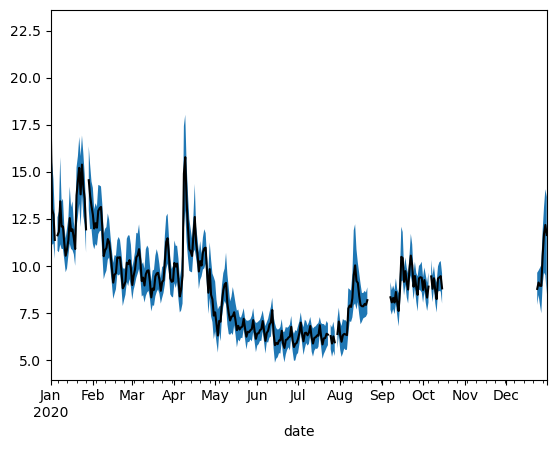

In [35]:
fig,ax=plt.subplots()
df_norm_unc.resample('1D').mean()['mean'].plot(c='k')
ax.fill_between(df_norm_unc.resample('1D').mean().index,df_norm_unc.resample('1D').mean()['lower_bound'],
                df_norm_unc.resample('1D').mean()['upper_bound'])


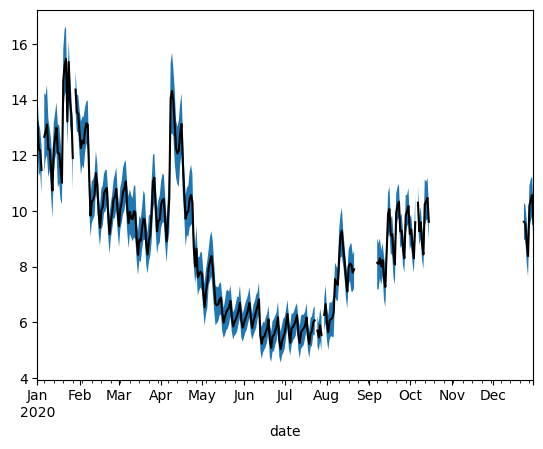

In [36]:
fig,ax=plt.subplots()
df_norm_unc_lgb.resample('1D').mean()['mean'].plot(c='k')
ax.fill_between(df_norm_unc_lgb.resample('1D').mean().index,df_norm_unc_lgb.resample('1D').mean()['lower_bound'],
                df_norm_unc_lgb.resample('1D').mean()['upper_bound'])
